# iTransformer Channel Information Permutation Test

This section implements functional-reliance interventions. Source histories are replaced using matched donor samples while the trained forecaster is kept fixed.


In [1]:
from pathlib import Path
from types import SimpleNamespace

import gc
import importlib
import math
import random
import sys
import warnings

import numpy as np
import pandas as pd

import torch
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings("ignore")

SEED = 2026

DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print("PyTorch:", torch.__version__)
print("Device:", DEVICE)

if DEVICE.type == "cuda":
    print(
        "GPU:",
        torch.cuda.get_device_name(0)
    )


PyTorch: 2.4.1+cu121
Device: cuda
GPU: NVIDIA A100-SXM4-80GB


## 1. Fixed screening protocol


In [2]:
SEQ_LEN = 96
LABEL_LEN = 48

ALL_HORIZONS = [
    96,
    192,
    336,
    720,
]

# Same eight diagnostic conditions used in the explicit hard-mask screening.
CONDITIONS = [
    ("Electricity", 192),
    ("Electricity", 336),

    ("Solar", 336),
    ("Solar", 720),

    ("Weather", 720),

    ("ETTh1", 336),
    ("ETTh1", 720),

    ("ETTm1", 720),
]

MAX_TOPK = 10
MAX_TARGET_CHANNELS = 32

# Three deterministic batch-permutation replicates.
PERTURB_SEEDS = [
    2026,
    2027,
    2028,
]

PERTURB_TYPES = [
    "AdaptiveTopK",
    "SharedTopK",
    "MatchedRandomK",
    "AllOtherChannels",
    "TargetSelf",
]

NUM_WORKERS = 2

PROJECT_ROOT = Path(
    "/data/code/2026_08"
)

BASELINE_ROOT = (
    PROJECT_ROOT
    / "results_external_baselines_phase1_direct"
)

# Teacher cache created by the previous hard-mask experiment.
TEACHER_CACHE_ROOT = (
    PROJECT_ROOT
    / "results_itransformer_explicit_sparse_horizon_mask"
    / "predictive_teacher_hardmask_cache"
)

# Previous results are used ONLY in final post-hoc correlation analysis.
RIDGE_REFERENCE = (
    PROJECT_ROOT
    / "results_rolling_temporal_stability_gate"
    / "stability_vs_controls.csv"
)

STRONG_MASK_REFERENCE = (
    PROJECT_ROOT
    / "results_itransformer_explicit_sparse_horizon_mask_v5"
    / "adaptive_vs_shared_paired.csv"
)

OUTPUT_DIR = (
    PROJECT_ROOT
    / "results_itransformer_channel_information_permutation"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

print("Teacher cache:", TEACHER_CACHE_ROOT)
print("Output:", OUTPUT_DIR)
print("Conditions:", CONDITIONS)
print("Perturb seeds:", PERTURB_SEEDS)


Teacher cache: /data/code/2026_08/results_itransformer_explicit_sparse_horizon_mask/predictive_teacher_hardmask_cache
Output: /data/code/2026_08/results_itransformer_channel_information_permutation
Conditions: [('Electricity', 192), ('Electricity', 336), ('Solar', 336), ('Solar', 720), ('Weather', 720), ('ETTh1', 336), ('ETTh1', 720), ('ETTm1', 720)]
Perturb seeds: [2026, 2027, 2028]


## 2. Determinism, K rule, and memory controls


In [3]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_seed(SEED)

if torch.cuda.is_available():
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True


def effective_topk(C):
    return int(
        max(
            1,
            min(
                MAX_TOPK,
                math.ceil(
                    (C - 1)
                    /
                    2
                ),
            ),
        )
    )


def choose_batch_size(
    dataset_name,
    H,
):
    if dataset_name == "Electricity":
        return (
            8
            if H >= 336
            else 12
        )

    if dataset_name == "Solar":
        return 16

    return 32


def choose_target_chunk(
    C,
    H,
):
    # Perturbation copies the batch once per target in the chunk.
    if C >= 300:
        return 3

    if C >= 100:
        return 4

    if H >= 720:
        return 6

    return 8


for C in [
    7,
    21,
    137,
    321,
]:
    print(
        f"C={C:3d} -> K={effective_topk(C)}"
    )


C=  7 -> K=3
C= 21 -> K=10
C=137 -> K=10
C=321 -> K=10


## 3. Locate Time-Series-Library and load iTransformer


In [4]:
TSLIB_CANDIDATES = [
    Path(
        "/data/Time-Series-Library"
    ),
    Path(
        "/data/Time-Series-Library_v2"
    ),
    Path(
        "/data/Time-Series-Library"
    ),
]


def is_tslib_root(p):
    p = Path(p)

    return (
        p.is_dir()
        and
        (
            p
            / "models"
            / "iTransformer.py"
        ).exists()
    )


TSL_ROOT = next(
    (
        p.resolve()
        for p in TSLIB_CANDIDATES
        if is_tslib_root(p)
    ),
    None,
)

if TSL_ROOT is None:
    raise FileNotFoundError(
        "Time-Series-Library source not found."
    )

if str(TSL_ROOT) not in sys.path:
    sys.path.insert(
        0,
        str(TSL_ROOT),
    )

iTransformer_module = importlib.import_module(
    "models.iTransformer"
)

print("TSLib:", TSL_ROOT)


TSLib: /data/Time-Series-Library


## 4. Dataset protocol identical to Phase-1


In [5]:
DATASET_CANDIDATES = {
    "Electricity": [
        "/data/dataset/electricity/electricity.csv",
        "/data/dataset/ECL/electricity.csv",
        "/data/dataset/electricity.csv",
    ],

    "Weather": [
        "/data/dataset/weather/weather.csv",
        "/data/dataset/weather.csv",
    ],

    "Solar": [
        "/data/dataset/solar/solar_AL.txt",
        "/data/dataset/Solar/solar_AL.txt",
        "/data/dataset/solar_AL.txt",
    ],

    "ETTh1": [
        "/data/dataset/ETT-small/ETTh1.csv",
        "/data/dataset/ETTh1.csv",
    ],

    "ETTm1": [
        "/data/dataset/ETT-small/ETTm1.csv",
        "/data/dataset/ETTm1.csv",
    ],
}


DATASET_SPECS = {
    "Electricity": {
        "channels": 321,
        "freq": "h",
    },

    "Weather": {
        "channels": 21,
        "freq": "t",
    },

    "Solar": {
        "channels": 137,
        "freq": "h",
    },

    "ETTh1": {
        "channels": 7,
        "freq": "h",
    },

    "ETTm1": {
        "channels": 7,
        "freq": "t",
    },
}


def resolve_path(candidates):
    for p in candidates:
        p = Path(p)

        if p.exists():
            return p.resolve()

    return None


DATASET_FILES = {}

for d, candidates in DATASET_CANDIDATES.items():
    path = resolve_path(
        candidates
    )

    if path is None:
        raise FileNotFoundError(
            f"{d}: dataset file not found."
        )

    DATASET_FILES[
        d
    ] = path

    print(
        f"{d:12s} -> {path}"
    )


Electricity  -> /data/dataset/electricity/electricity.csv
Weather      -> /data/dataset/weather/weather.csv
Solar        -> /data/dataset/solar/solar_AL.txt
ETTh1        -> /data/dataset/ETT-small/ETTh1.csv
ETTm1        -> /data/dataset/ETT-small/ETTm1.csv


In [6]:
def load_numeric_series(
    dataset_name,
    path,
):
    path = Path(path)

    if path.suffix.lower() == ".csv":
        df = pd.read_csv(
            path
        )

        date_col = None

        for candidate in [
            "date",
            "datetime",
            "timestamp",
            "time",
        ]:
            if candidate in df.columns:
                date_col = candidate
                break

        if date_col is None:
            first = df.columns[
                0
            ]

            if not pd.api.types.is_numeric_dtype(
                df[
                    first
                ]
            ):
                date_col = first

        if date_col is not None:
            df = df.drop(
                columns=[
                    date_col
                ]
            )

        df = df.select_dtypes(
            include=[
                np.number
            ]
        )

        x = df.to_numpy(
            dtype=np.float32
        )

    else:
        try:
            x = np.loadtxt(
                path,
                delimiter=",",
                dtype=np.float32,
            )

        except Exception:
            x = np.loadtxt(
                path,
                dtype=np.float32,
            )

        if x.ndim == 1:
            x = x[
                :,
                None
            ]

    if x.ndim != 2:
        raise ValueError(
            f"{dataset_name}: expected [T,C], got {x.shape}"
        )

    if not np.isfinite(
        x
    ).all():
        raise ValueError(
            f"{dataset_name}: non-finite values"
        )

    return x


def split_boundaries(
    dataset_name,
    T,
):
    if dataset_name == "ETTh1":
        train_end = (
            12
            *
            30
            *
            24
        )

        val_end = (
            train_end
            +
            4
            *
            30
            *
            24
        )

        test_end = (
            val_end
            +
            4
            *
            30
            *
            24
        )

        return (
            min(
                train_end,
                T,
            ),
            min(
                val_end,
                T,
            ),
            min(
                test_end,
                T,
            ),
        )

    if dataset_name == "ETTm1":
        unit = (
            30
            *
            24
            *
            4
        )

        train_end = (
            12
            *
            unit
        )

        val_end = (
            train_end
            +
            4
            *
            unit
        )

        test_end = (
            val_end
            +
            4
            *
            unit
        )

        return (
            min(
                train_end,
                T,
            ),
            min(
                val_end,
                T,
            ),
            min(
                test_end,
                T,
            ),
        )

    return (
        int(
            0.70
            *
            T
        ),
        int(
            0.80
            *
            T
        ),
        T,
    )


def load_and_normalize(
    dataset_name,
):
    raw = load_numeric_series(
        dataset_name,
        DATASET_FILES[
            dataset_name
        ],
    )

    T, C = raw.shape

    (
        train_end,
        val_end,
        test_end,
    ) = split_boundaries(
        dataset_name,
        T,
    )

    mean = raw[
        :train_end
    ].mean(
        axis=0,
        keepdims=True,
    )

    std = raw[
        :train_end
    ].std(
        axis=0,
        keepdims=True,
    )

    std = np.maximum(
        std,
        1e-6,
    )

    x = (
        raw
        -
        mean
    ) / std

    return (
        x.astype(
            np.float32
        ),
        {
            "T": T,
            "C": C,
            "train_end": train_end,
            "val_end": val_end,
            "test_end": test_end,
        },
    )


class ForecastDataset(
    Dataset
):
    def __init__(
        self,
        data,
        seq_len,
        label_len,
        pred_len,
        target_start_min,
        target_end_exclusive,
    ):
        self.data = torch.from_numpy(
            data
        ).float()

        self.seq_len = int(
            seq_len
        )

        self.label_len = int(
            label_len
        )

        self.pred_len = int(
            pred_len
        )

        first_t = max(
            self.seq_len,
            self.label_len,
            int(
                target_start_min
            ),
        )

        last_t = (
            int(
                target_end_exclusive
            )
            -
            self.pred_len
        )

        self.origins = np.arange(
            first_t,
            last_t + 1,
            dtype=np.int64,
        )

        if len(
            self.origins
        ) == 0:
            raise RuntimeError(
                "No valid forecasting windows."
            )

    def __len__(
        self,
    ):
        return len(
            self.origins
        )

    def __getitem__(
        self,
        idx,
    ):
        t = int(
            self.origins[
                idx
            ]
        )

        x = self.data[
            t-self.seq_len:
            t
        ]

        y = self.data[
            t-self.label_len:
            t+self.pred_len
        ]

        return x, y


def prepare_test_dataset(
    dataset_name,
    H,
):
    x, meta = load_and_normalize(
        dataset_name
    )

    expected_C = DATASET_SPECS[
        dataset_name
    ][
        "channels"
    ]

    if meta[
        "C"
    ] != expected_C:
        raise RuntimeError(
            f"{dataset_name}: detected C={meta['C']}, "
            f"expected {expected_C}"
        )

    test_ds = ForecastDataset(
        x,
        SEQ_LEN,
        LABEL_LEN,
        H,
        target_start_min=meta[
            "val_end"
        ],
        target_end_exclusive=meta[
            "test_end"
        ],
    )

    return (
        x,
        test_ds,
        meta,
    )


def make_test_loader(
    test_ds,
    batch_size,
):
    return DataLoader(
        test_ds,
        batch_size=batch_size,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=torch.cuda.is_available(),
        drop_last=False,
    )


## 5. Exact Phase-1 checkpoint loader


In [7]:
def build_itransformer_args(
    dataset_name,
    H,
):
    spec = DATASET_SPECS[
        dataset_name
    ]

    return SimpleNamespace(
        task_name="long_term_forecast",
        model="iTransformer",

        seq_len=SEQ_LEN,
        label_len=LABEL_LEN,
        pred_len=H,

        enc_in=spec[
            "channels"
        ],
        dec_in=spec[
            "channels"
        ],
        c_out=spec[
            "channels"
        ],

        e_layers=3,
        d_layers=1,
        n_heads=8,
        d_model=512,
        d_ff=512,
        factor=3,
        dropout=0.1,

        embed="timeF",
        freq=spec[
            "freq"
        ],
        activation="gelu",
        output_attention=False,

        class_strategy="projection",
        use_norm=1,

        moving_avg=25,
        distil=True,
        top_k=5,
        num_kernels=6,
        seasonal_patterns="Monthly",
        inverse=False,
    )


def condition_dir(
    dataset_name,
    H,
):
    return (
        BASELINE_ROOT
        / "iTransformer"
        / dataset_name
        / f"H{H}"
    )


def build_and_load_itransformer(
    dataset_name,
    H,
):
    args = build_itransformer_args(
        dataset_name,
        H,
    )

    model = (
        iTransformer_module
        .Model(
            args
        )
        .float()
        .to(
            DEVICE
        )
    )

    checkpoint = (
        condition_dir(
            dataset_name,
            H,
        )
        / "best_model.pt"
    )

    if not checkpoint.exists():
        raise FileNotFoundError(
            checkpoint
        )

    state = torch.load(
        checkpoint,
        map_location="cpu",
    )

    model.load_state_dict(
        state,
        strict=True,
    )

    model.eval()

    return model


def load_phase1_result(
    dataset_name,
    H,
):
    path = (
        condition_dir(
            dataset_name,
            H,
        )
        / "result.csv"
    )

    if not path.exists():
        raise FileNotFoundError(
            path
        )

    df = pd.read_csv(
        path
    )

    if len(
        df
    ) != 1:
        raise RuntimeError(
            f"Unexpected result rows: {path}"
        )

    return df.iloc[
        0
    ].to_dict()


## 6. Target sampling


In [8]:
def choose_targets(
    C,
):
    if C <= MAX_TARGET_CHANNELS:
        return np.arange(
            C,
            dtype=np.int64,
        )

    return np.unique(
        np.linspace(
            0,
            C - 1,
            MAX_TARGET_CHANNELS,
            dtype=np.int64,
        )
    )


for d in sorted(
    {
        x[
            0
        ]
        for x in CONDITIONS
    }
):
    C = DATASET_SPECS[
        d
    ][
        "channels"
    ]

    print(
        f"{d:12s}: C={C}, "
        f"targets={len(choose_targets(C))}, "
        f"K={effective_topk(C)}"
    )


ETTh1       : C=7, targets=7, K=3
ETTm1       : C=7, targets=7, K=3
Electricity : C=321, targets=32, K=10
Solar       : C=137, targets=32, K=10
Weather     : C=21, targets=21, K=10


## 7. Load Adaptive and Shared source sets from training-only teacher cache


In [9]:
def hardmask_teacher_path(
    dataset_name,
    H,
    K,
):
    return (
        TEACHER_CACHE_ROOT
        / (
            f"{dataset_name}_H{H}_"
            f"endpoint_predictive_topk_K{K}.npz"
        )
    )


def load_adaptive_sources(
    dataset_name,
    H,
    C,
    K,
):
    path = hardmask_teacher_path(
        dataset_name,
        H,
        K,
    )

    if not path.exists():
        raise FileNotFoundError(
            f"Missing teacher cache: {path}\n"
            f"Run the v5.1 explicit sparse-mask notebook first."
        )

    cache = np.load(
        path
    )

    idx = cache[
        "source_idx"
    ].astype(
        np.int64
    )

    gain = cache[
        "source_gain"
    ].astype(
        np.float32
    )

    if idx.shape != (
        C,
        K,
    ):
        raise RuntimeError(
            f"{dataset_name} H={H}: "
            f"source_idx shape={idx.shape}, "
            f"expected {(C,K)}"
        )

    return (
        idx,
        gain,
    )


def build_shared_consensus_sources(
    dataset_name,
    C,
    K,
):
    """
    Exact same Borda-style horizon consensus used in the previous
    explicit hard-mask experiment.
    """
    rankings = {}

    for H in ALL_HORIZONS:
        idx, gain = load_adaptive_sources(
            dataset_name,
            H,
            C,
            K,
        )

        rankings[
            H
        ] = (
            idx,
            gain,
        )

    shared = np.zeros(
        (
            C,
            K,
        ),
        dtype=np.int64,
    )

    for i in range(
        C
    ):
        score = {}
        freq = {}
        gain_sum = {}

        for H in ALL_HORIZONS:
            idx, gain = rankings[
                H
            ]

            for rank, (
                j,
                g,
            ) in enumerate(
                zip(
                    idx[
                        i
                    ].tolist(),
                    gain[
                        i
                    ].tolist(),
                )
            ):
                j = int(
                    j
                )

                score[
                    j
                ] = (
                    score.get(
                        j,
                        0.0,
                    )
                    +
                    float(
                        K - rank
                    )
                )

                freq[
                    j
                ] = (
                    freq.get(
                        j,
                        0
                    )
                    +
                    1
                )

                gain_sum[
                    j
                ] = (
                    gain_sum.get(
                        j,
                        0.0,
                    )
                    +
                    float(
                        g
                    )
                )

        candidates = list(
            score.keys()
        )

        candidates.sort(
            key=lambda j: (
                score[
                    j
                ],
                freq[
                    j
                ],
                gain_sum[
                    j
                ],
            ),
            reverse=True,
        )

        if len(
            candidates
        ) < K:
            raise RuntimeError(
                f"{dataset_name} target={i}: "
                f"shared candidate union < K"
            )

        shared[
            i
        ] = np.asarray(
            candidates[
                :K
            ],
            dtype=np.int64,
        )

    return shared


def mean_set_jaccard(
    A,
    B,
):
    vals = []

    for a, b in zip(
        A,
        B,
    ):
        sa = set(
            a.tolist()
        )

        sb = set(
            b.tolist()
        )

        vals.append(
            len(
                sa
                &
                sb
            )
            /
            max(
                1,
                len(
                    sa
                    |
                    sb
                ),
            )
        )

    return float(
        np.mean(
            vals
        )
    )


source_summary_rows = []

for d, H in CONDITIONS:
    C = DATASET_SPECS[
        d
    ][
        "channels"
    ]

    K = effective_topk(
        C
    )

    adaptive, _ = load_adaptive_sources(
        d,
        H,
        C,
        K,
    )

    shared = build_shared_consensus_sources(
        d,
        C,
        K,
    )

    source_summary_rows.append(
        {
            "dataset": d,
            "pred_len": H,
            "C": C,
            "K": K,
            "shared_adaptive_jaccard": (
                mean_set_jaccard(
                    shared,
                    adaptive,
                )
            ),
        }
    )

source_summary = pd.DataFrame(
    source_summary_rows
)

display(
    source_summary.round(
        4
    )
)


,dataset,pred_len,C,K,shared_adaptive_jaccard
0,Electricity,192,321,10,0.5504
1,Electricity,336,321,10,0.4867
2,Solar,336,137,10,0.6527
3,Solar,720,137,10,0.1221
4,Weather,720,21,10,0.6343
5,ETTh1,336,7,3,0.7429
6,ETTh1,720,7,3,0.9286
7,ETTm1,720,7,3,0.8571


## 8. Matched random source sets


In [10]:
def deterministic_random_sources(
    C,
    K,
    target_idx,
    adaptive_sources,
    seed,
):
    """
    Random-K control.

    Prefer sources outside AdaptiveTopK so the random control does not
    accidentally contain the exact teacher-selected channels.

    For C=7, K=3:
      non-target = 6
      adaptive = 3
      complement = 3
    so the complement is exactly usable.
    """
    adaptive_set = set(
        int(x)
        for x in adaptive_sources
    )

    complement = [
        j
        for j in range(
            C
        )
        if (
            j != target_idx
            and
            j not in adaptive_set
        )
    ]

    if len(
        complement
    ) >= K:
        pool = complement

    else:
        pool = [
            j
            for j in range(
                C
            )
            if j != target_idx
        ]

    local_rng = np.random.default_rng(
        int(
            seed
            +
            1000003
            *
            (
                target_idx
                +
                1
            )
        )
    )

    selected = local_rng.choice(
        pool,
        size=K,
        replace=False,
    )

    return np.asarray(
        selected,
        dtype=np.int64,
    )


## 9. Conditional batch permutation


In [11]:
def deterministic_batch_shift(
    B,
    perturb_seed,
    target_idx,
    batch_index,
):
    """
    Non-zero cyclic shift.

    Unlike randperm, this guarantees that every sample is paired with
    a different sample whenever B > 1.
    """
    if B <= 1:
        return None

    value = (
        int(
            perturb_seed
        )
        *
        1000003
        +
        int(
            target_idx
        )
        *
        9176
        +
        int(
            batch_index
        )
        *
        131
    )

    return (
        1
        +
        (
            value
            %
            (
                B - 1
            )
        )
    )


def perturb_target_chunk(
    x,
    targets_chunk,
    source_sets,
    perturb_seed,
    batch_index,
):
    """
    x:
        [B,L,C]

    targets_chunk:
        list/array of target channel indices

    source_sets:
        list of arrays; one source set per target

    Returns:
        [Tchunk*B, L, C]

    Each target receives its own perturbed copy of the same clean batch.
    """
    B, L, C = x.shape

    Tn = len(
        targets_chunk
    )

    aug = (
        x[
            None,
            :,
            :,
            :
        ]
        .expand(
            Tn,
            B,
            L,
            C,
        )
        .clone()
    )

    for q, (
        target_idx,
        sources,
    ) in enumerate(
        zip(
            targets_chunk,
            source_sets,
        )
    ):
        sources = np.asarray(
            sources,
            dtype=np.int64,
        )

        if len(
            sources
        ) == 0:
            continue

        shift = deterministic_batch_shift(
            B,
            perturb_seed,
            int(
                target_idx
            ),
            batch_index,
        )

        if shift is not None:
            donor_idx = torch.roll(
                torch.arange(
                    B,
                    device=x.device,
                ),
                shifts=shift,
                dims=0,
            )

            donor = x[
                donor_idx
            ]

            aug[
                q,
                :,
                :,
                sources,
            ] = donor[
                :,
                :,
                sources,
            ]

        else:
            # Extremely rare final batch with B=1.
            # Preserve values but break temporal alignment.
            donor = torch.flip(
                x,
                dims=[
                    1
                ],
            )

            aug[
                q,
                :,
                :,
                sources,
            ] = donor[
                :,
                :,
                sources,
            ]

    return aug.reshape(
        Tn
        *
        B,
        L,
        C,
    )


## 10. Source set generator for each perturbation


In [12]:
def source_sets_for_type(
    perturb_type,
    targets_chunk,
    adaptive_sources,
    shared_sources,
    C,
    K,
    perturb_seed,
):
    result = []

    for target_idx in targets_chunk:
        i = int(
            target_idx
        )

        if perturb_type == "AdaptiveTopK":
            sources = adaptive_sources[
                i
            ]

        elif perturb_type == "SharedTopK":
            sources = shared_sources[
                i
            ]

        elif perturb_type == "MatchedRandomK":
            sources = deterministic_random_sources(
                C,
                K,
                i,
                adaptive_sources[
                    i
                ],
                perturb_seed,
            )

        elif perturb_type == "AllOtherChannels":
            sources = np.asarray(
                [
                    j
                    for j in range(
                        C
                    )
                    if j != i
                ],
                dtype=np.int64,
            )

        elif perturb_type == "TargetSelf":
            sources = np.asarray(
                [
                    i
                ],
                dtype=np.int64,
            )

        else:
            raise ValueError(
                perturb_type
            )

        result.append(
            np.asarray(
                sources,
                dtype=np.int64,
            )
        )

    return result


## 11. Per-condition inference intervention


In [13]:
@torch.inference_mode()
def run_condition(
    dataset_name,
    H,
):
    _, test_ds, meta = prepare_test_dataset(
        dataset_name,
        H,
    )

    C = int(
        meta[
            "C"
        ]
    )

    K = effective_topk(
        C
    )

    targets = choose_targets(
        C
    )

    adaptive_sources, _ = load_adaptive_sources(
        dataset_name,
        H,
        C,
        K,
    )

    shared_sources = build_shared_consensus_sources(
        dataset_name,
        C,
        K,
    )

    batch_size = choose_batch_size(
        dataset_name,
        H,
    )

    target_chunk = choose_target_chunk(
        C,
        H,
    )

    loader = make_test_loader(
        test_ds,
        batch_size,
    )

    model = build_and_load_itransformer(
        dataset_name,
        H,
    )

    model.eval()

    n_targets = len(
        targets
    )

    target_to_pos = {
        int(
            t
        ): q
        for q, t in enumerate(
            targets
        )
    }

    # Clean accumulators per target.
    clean_full_sse = np.zeros(
        n_targets,
        dtype=np.float64,
    )

    clean_endpoint_sse = np.zeros(
        n_targets,
        dtype=np.float64,
    )

    clean_full_n = np.zeros(
        n_targets,
        dtype=np.int64,
    )

    clean_endpoint_n = np.zeros(
        n_targets,
        dtype=np.int64,
    )

    # Full-channel fidelity against stored Phase-1.
    all_channel_sse = 0.0
    all_channel_n = 0

    # perturb_sse[(type,seed)] -> arrays per target
    perturb_full_sse = {}
    perturb_endpoint_sse = {}

    for ptype in PERTURB_TYPES:
        for pseed in PERTURB_SEEDS:
            perturb_full_sse[
                (
                    ptype,
                    pseed,
                )
            ] = np.zeros(
                n_targets,
                dtype=np.float64,
            )

            perturb_endpoint_sse[
                (
                    ptype,
                    pseed,
                )
            ] = np.zeros(
                n_targets,
                dtype=np.float64,
            )

    print(
        f"{dataset_name} H={H}: "
        f"C={C}, K={K}, targets={n_targets}, "
        f"batch={batch_size}, target_chunk={target_chunk}"
    )

    for batch_index, (
        x,
        y,
    ) in enumerate(
        loader
    ):
        x = x.float().to(
            DEVICE,
            non_blocking=True,
        )

        y = y.float().to(
            DEVICE,
            non_blocking=True,
        )

        target_full = y[
            :,
            -H:,
            :
        ]

        clean_pred = model(
            x,
            None,
            None,
            None,
        )[
            :,
            -H:,
            :
        ]

        clean_err_all = (
            clean_pred
            -
            target_full
        )

        all_channel_sse += (
            clean_err_all
            .square()
            .sum()
            .item()
        )

        all_channel_n += (
            clean_err_all
            .numel()
        )

        # Clean target-specific errors.
        for q, target_idx in enumerate(
            targets
        ):
            err = (
                clean_pred[
                    :,
                    :,
                    target_idx,
                ]
                -
                target_full[
                    :,
                    :,
                    target_idx,
                ]
            )

            clean_full_sse[
                q
            ] += (
                err.square()
                .sum()
                .item()
            )

            clean_endpoint_sse[
                q
            ] += (
                err[
                    :,
                    -1
                ]
                .square()
                .sum()
                .item()
            )

            clean_full_n[
                q
            ] += (
                err.numel()
            )

            clean_endpoint_n[
                q
            ] += (
                err.shape[
                    0
                ]
            )

        # Perturb target chunks.
        for start in range(
            0,
            n_targets,
            target_chunk,
        ):
            chunk = targets[
                start:
                start
                +
                target_chunk
            ]

            for ptype in PERTURB_TYPES:
                for pseed in PERTURB_SEEDS:
                    source_sets = source_sets_for_type(
                        ptype,
                        chunk,
                        adaptive_sources,
                        shared_sources,
                        C,
                        K,
                        pseed,
                    )

                    x_aug = perturb_target_chunk(
                        x,
                        chunk,
                        source_sets,
                        pseed,
                        batch_index,
                    )

                    pred_aug = model(
                        x_aug,
                        None,
                        None,
                        None,
                    )[
                        :,
                        -H:,
                        :
                    ]

                    Tn = len(
                        chunk
                    )

                    B = x.shape[
                        0
                    ]

                    pred_aug = pred_aug.reshape(
                        Tn,
                        B,
                        H,
                        C,
                    )

                    for local_q, target_idx in enumerate(
                        chunk
                    ):
                        global_q = target_to_pos[
                            int(
                                target_idx
                            )
                        ]

                        err = (
                            pred_aug[
                                local_q,
                                :,
                                :,
                                target_idx,
                            ]
                            -
                            target_full[
                                :,
                                :,
                                target_idx,
                            ]
                        )

                        perturb_full_sse[
                            (
                                ptype,
                                pseed,
                            )
                        ][
                            global_q
                        ] += (
                            err.square()
                            .sum()
                            .item()
                        )

                        perturb_endpoint_sse[
                            (
                                ptype,
                                pseed,
                            )
                        ][
                            global_q
                        ] += (
                            err[
                                :,
                                -1
                            ]
                            .square()
                            .sum()
                            .item()
                        )

                    del (
                        x_aug,
                        pred_aug,
                    )

        if (
            batch_index
            %
            20
            ==
            0
        ):
            print(
                f"  batch {batch_index+1}/{len(loader)}"
            )

    # Phase-1 fidelity.
    clean_all_mse = (
        all_channel_sse
        /
        all_channel_n
    )

    stored = load_phase1_result(
        dataset_name,
        H,
    )

    stored_mse = float(
        stored[
            "test_mse"
        ]
    )

    fidelity = abs(
        clean_all_mse
        -
        stored_mse
    )

    print(
        f"  checkpoint fidelity: "
        f"stored={stored_mse:.6f}, "
        f"clean={clean_all_mse:.6f}, "
        f"abs_diff={fidelity:.3e}"
    )

    if fidelity >= 2e-5:
        raise AssertionError(
            f"Phase-1 fidelity failed: {fidelity}"
        )

    rows = []

    for q, target_idx in enumerate(
        targets
    ):
        clean_full_mse = (
            clean_full_sse[
                q
            ]
            /
            clean_full_n[
                q
            ]
        )

        clean_endpoint_mse = (
            clean_endpoint_sse[
                q
            ]
            /
            clean_endpoint_n[
                q
            ]
        )

        for ptype in PERTURB_TYPES:
            for pseed in PERTURB_SEEDS:
                pfull = (
                    perturb_full_sse[
                        (
                            ptype,
                            pseed,
                        )
                    ][
                        q
                    ]
                    /
                    clean_full_n[
                        q
                    ]
                )

                pend = (
                    perturb_endpoint_sse[
                        (
                            ptype,
                            pseed,
                        )
                    ][
                        q
                    ]
                    /
                    clean_endpoint_n[
                        q
                    ]
                )

                full_deg = (
                    100.0
                    *
                    (
                        pfull
                        -
                        clean_full_mse
                    )
                    /
                    max(
                        clean_full_mse,
                        1e-12,
                    )
                )

                endpoint_deg = (
                    100.0
                    *
                    (
                        pend
                        -
                        clean_endpoint_mse
                    )
                    /
                    max(
                        clean_endpoint_mse,
                        1e-12,
                    )
                )

                rows.append(
                    {
                        "dataset": dataset_name,
                        "pred_len": int(
                            H
                        ),
                        "target_channel": int(
                            target_idx
                        ),
                        "C": C,
                        "K": K,

                        "perturb_type": ptype,
                        "perturb_seed": int(
                            pseed
                        ),

                        "clean_full_mse": (
                            clean_full_mse
                        ),
                        "perturbed_full_mse": (
                            pfull
                        ),
                        "full_degradation_%": (
                            full_deg
                        ),

                        "clean_endpoint_mse": (
                            clean_endpoint_mse
                        ),
                        "perturbed_endpoint_mse": (
                            pend
                        ),
                        "endpoint_degradation_%": (
                            endpoint_deg
                        ),

                        "clean_full_sse": float(
                            clean_full_sse[
                                q
                            ]
                        ),
                        "perturbed_full_sse": float(
                            perturb_full_sse[
                                (
                                    ptype,
                                    pseed,
                                )
                            ][
                                q
                            ]
                        ),
                        "full_n": int(
                            clean_full_n[
                                q
                            ]
                        ),

                        "clean_endpoint_sse": float(
                            clean_endpoint_sse[
                                q
                            ]
                        ),
                        "perturbed_endpoint_sse": float(
                            perturb_endpoint_sse[
                                (
                                    ptype,
                                    pseed,
                                )
                            ][
                                q
                            ]
                        ),
                        "endpoint_n": int(
                            clean_endpoint_n[
                                q
                            ]
                        ),
                    }
                )

    result = pd.DataFrame(
        rows
    )

    del (
        model,
        loader,
        test_ds,
    )

    gc.collect()

    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()

    return result


## 12. Pre-flight on ETTh1 H336


In [14]:
preflight = run_condition(
    "ETTh1",
    336,
)

print(
    "Pre-flight rows:",
    len(
        preflight
    )
)

display(
    preflight.head()
)

# Sanity:
# TargetSelf should generally be much more damaging than random source removal.
preflight_mean = (
    preflight
    .groupby(
        "perturb_type"
    )[
        [
            "full_degradation_%",
            "endpoint_degradation_%",
        ]
    ]
    .mean()
)

display(
    preflight_mean.round(
        3
    )
)

print(
    "\nPre-flight: PASSED"
)


ETTh1 H=336: C=7, K=3, targets=7, batch=32, target_chunk=8
  batch 1/80
  batch 21/80
  batch 41/80
  batch 61/80
  checkpoint fidelity: stored=0.476863, clean=0.476864, abs_diff=6.754e-08
Pre-flight rows: 105


,dataset,pred_len,target_channel,C,K,perturb_type,perturb_seed,clean_full_mse,perturbed_full_mse,full_degradation_%,clean_endpoint_mse,perturbed_endpoint_mse,endpoint_degradation_%,clean_full_sse,perturbed_full_sse,full_n,clean_endpoint_sse,perturbed_endpoint_sse,endpoint_n
0,ETTh1,336,0,7,3,AdaptiveTopK,2026,0.987649,0.991970,0.437560,1.117602,1.111665,-0.531220,844558.317871,848253.770996,855120,2844.297185,2829.187712,2545
1,ETTh1,336,0,7,3,AdaptiveTopK,2027,0.987649,0.993127,0.554690,1.117602,1.120296,0.241081,844558.317871,849242.994629,855120,2844.297185,2851.154244,2545
2,ETTh1,336,0,7,3,AdaptiveTopK,2028,0.987649,0.994620,0.705851,1.117602,1.125633,0.718562,844558.317871,850519.643555,855120,2844.297185,2864.735222,2545
3,ETTh1,336,0,7,3,SharedTopK,2026,0.987649,0.991970,0.437560,1.117602,1.111665,-0.531220,844558.317871,848253.770996,855120,2844.297185,2829.187712,2545
4,ETTh1,336,0,7,3,SharedTopK,2027,0.987649,0.993127,0.554690,1.117602,1.120296,0.241081,844558.317871,849242.994629,855120,2844.297185,2851.154244,2545


,full_degradation_%,endpoint_degradation_%
perturb_type,,
AdaptiveTopK,0.585,0.645
AllOtherChannels,1.339,1.597
MatchedRandomK,0.597,0.909
SharedTopK,0.399,0.419
TargetSelf,80.044,65.440



Pre-flight: PASSED


## 13. Run all screening conditions with resume


In [15]:
all_frames = []
failures = []

for dataset_name, H in CONDITIONS:
    print(
        "\n"
        +
        "="
        *
        100
    )

    print(
        f"{dataset_name} H={H}"
    )

    print(
        "="
        *
        100
    )

    path = (
        OUTPUT_DIR
        /
        f"{dataset_name}_H{H}_target_perturbation_rows.csv"
    )

    if path.exists():
        print(
            "Reusing completed condition."
        )

        df = pd.read_csv(
            path
        )

        all_frames.append(
            df
        )

        continue

    try:
        df = run_condition(
            dataset_name,
            H,
        )

        df.to_csv(
            path,
            index=False,
        )

        all_frames.append(
            df
        )

    except Exception as e:
        failures.append(
            {
                "dataset": dataset_name,
                "pred_len": H,
                "error": repr(
                    e
                ),
            }
        )

        print(
            "FAILED:",
            repr(
                e
            )
        )

    gc.collect()

    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()


if len(
    all_frames
) == 0:
    raise RuntimeError(
        "No condition completed."
    )

rows_all = pd.concat(
    all_frames,
    ignore_index=True,
)

rows_all.to_csv(
    OUTPUT_DIR
    / "target_perturbation_rows_all.csv",
    index=False,
)

pd.DataFrame(
    failures
).to_csv(
    OUTPUT_DIR
    / "failures.csv",
    index=False,
)

print(
    "Rows:",
    len(
        rows_all
    )
)

print(
    "Completed conditions:",
    rows_all[
        [
            "dataset",
            "pred_len",
        ]
    ]
    .drop_duplicates()
    .shape[
        0
    ]
)

print(
    "Failures:",
    len(
        failures
    )
)



Electricity H=192
Electricity H=192: C=321, K=10, targets=32, batch=12, target_chunk=3
  batch 1/423
  batch 21/423
  batch 41/423
  batch 61/423
  batch 81/423
  batch 101/423
  batch 121/423
  batch 141/423
  batch 161/423
  batch 181/423
  batch 201/423
  batch 221/423
  batch 241/423
  batch 261/423
  batch 281/423
  batch 301/423
  batch 321/423
  batch 341/423
  batch 361/423
  batch 381/423
  batch 401/423
  batch 421/423
  checkpoint fidelity: stored=0.164334, clean=0.164334, abs_diff=3.625e-08

Electricity H=336
Electricity H=336: C=321, K=10, targets=32, batch=8, target_chunk=3
  batch 1/616
  batch 21/616
  batch 41/616
  batch 61/616
  batch 81/616
  batch 101/616
  batch 121/616
  batch 141/616
  batch 161/616
  batch 181/616
  batch 201/616
  batch 221/616
  batch 241/616
  batch 261/616
  batch 281/616
  batch 301/616
  batch 321/616
  batch 341/616
  batch 361/616
  batch 381/616
  batch 401/616
  batch 421/616
  batch 441/616
  batch 461/616
  batch 481/616
  batch 50

## 14. Robust pooled perturbation degradation


In [16]:
def summarize_condition_perturbation(
    df,
):
    rows = []

    for (
        dataset,
        H,
        ptype,
    ), sub in df.groupby(
        [
            "dataset",
            "pred_len",
            "perturb_type",
        ]
    ):
        # Each clean target is repeated once per perturb seed.
        clean_full_sse = sub[
            "clean_full_sse"
        ].sum()

        perturb_full_sse = sub[
            "perturbed_full_sse"
        ].sum()

        full_n = sub[
            "full_n"
        ].sum()

        clean_endpoint_sse = sub[
            "clean_endpoint_sse"
        ].sum()

        perturb_endpoint_sse = sub[
            "perturbed_endpoint_sse"
        ].sum()

        endpoint_n = sub[
            "endpoint_n"
        ].sum()

        clean_full_mse = (
            clean_full_sse
            /
            full_n
        )

        perturb_full_mse = (
            perturb_full_sse
            /
            full_n
        )

        clean_endpoint_mse = (
            clean_endpoint_sse
            /
            endpoint_n
        )

        perturb_endpoint_mse = (
            perturb_endpoint_sse
            /
            endpoint_n
        )

        rows.append(
            {
                "dataset": dataset,
                "pred_len": int(
                    H
                ),
                "perturb_type": ptype,

                "pooled_clean_full_mse": (
                    clean_full_mse
                ),
                "pooled_perturbed_full_mse": (
                    perturb_full_mse
                ),

                "pooled_full_degradation_%": (
                    100.0
                    *
                    (
                        perturb_full_mse
                        -
                        clean_full_mse
                    )
                    /
                    max(
                        clean_full_mse,
                        1e-12,
                    )
                ),

                "pooled_clean_endpoint_mse": (
                    clean_endpoint_mse
                ),
                "pooled_perturbed_endpoint_mse": (
                    perturb_endpoint_mse
                ),

                "pooled_endpoint_degradation_%": (
                    100.0
                    *
                    (
                        perturb_endpoint_mse
                        -
                        clean_endpoint_mse
                    )
                    /
                    max(
                        clean_endpoint_mse,
                        1e-12,
                    )
                ),

                "median_target_full_degradation_%": float(
                    sub.groupby(
                        "target_channel"
                    )[
                        "full_degradation_%"
                    ]
                    .mean()
                    .median()
                ),

                "median_target_endpoint_degradation_%": float(
                    sub.groupby(
                        "target_channel"
                    )[
                        "endpoint_degradation_%"
                    ]
                    .mean()
                    .median()
                ),

                "positive_target_endpoint_fraction": float(
                    (
                        sub.groupby(
                            "target_channel"
                        )[
                            "endpoint_degradation_%"
                        ]
                        .mean()
                        >
                        0
                    )
                    .mean()
                ),
            }
        )

    return pd.DataFrame(
        rows
    )


condition_summary = summarize_condition_perturbation(
    rows_all
)

condition_summary.to_csv(
    OUTPUT_DIR
    / "condition_perturbation_summary.csv",
    index=False,
)

endpoint_pivot = condition_summary.pivot_table(
    index=[
        "dataset",
        "pred_len",
    ],
    columns="perturb_type",
    values="pooled_endpoint_degradation_%",
    aggfunc="first",
)

display(
    endpoint_pivot.round(
        3
    )
)


perturb_type          AdaptiveTopK  AllOtherChannels  MatchedRandomK  \
dataset     pred_len                                                   
ETTh1       336              0.697             1.869           1.067   
            720              0.584             4.008           4.015   
ETTm1       720             -0.469             1.671           1.069   
Electricity 192              1.394            53.315           1.106   
            336              1.964             7.750           1.054   
Solar       336              5.916            17.538           4.185   
            720              3.563            19.412           4.097   
Weather     720             -0.164            -0.227          -0.460   

perturb_type          SharedTopK  TargetSelf  
dataset     pred_len                          
ETTh1       336            0.379      92.756  
            720            0.544      82.066  
ETTm1       720            0.367      50.837  
Electricity 192            1.398     431.977  
            336            1.955     305.716  
Solar       336            6.357      14.139  
            720            5.941      12.350  
Weather     720           -0.093       1.048

## 15. Decisive source-importance comparisons


In [17]:
full_pivot = condition_summary.pivot_table(
    index=[
        "dataset",
        "pred_len",
    ],
    columns="perturb_type",
    values="pooled_full_degradation_%",
    aggfunc="first",
).reset_index()

endpoint_pivot2 = condition_summary.pivot_table(
    index=[
        "dataset",
        "pred_len",
    ],
    columns="perturb_type",
    values="pooled_endpoint_degradation_%",
    aggfunc="first",
).reset_index()

comparison = full_pivot.merge(
    endpoint_pivot2,
    on=[
        "dataset",
        "pred_len",
    ],
    suffixes=(
        "_full",
        "_endpoint",
    ),
    validate="one_to_one",
)

comparison[
    "adaptive_minus_random_full_pp"
] = (
    comparison[
        "AdaptiveTopK_full"
    ]
    -
    comparison[
        "MatchedRandomK_full"
    ]
)

comparison[
    "adaptive_minus_random_endpoint_pp"
] = (
    comparison[
        "AdaptiveTopK_endpoint"
    ]
    -
    comparison[
        "MatchedRandomK_endpoint"
    ]
)

comparison[
    "adaptive_minus_shared_full_pp"
] = (
    comparison[
        "AdaptiveTopK_full"
    ]
    -
    comparison[
        "SharedTopK_full"
    ]
)

comparison[
    "adaptive_minus_shared_endpoint_pp"
] = (
    comparison[
        "AdaptiveTopK_endpoint"
    ]
    -
    comparison[
        "SharedTopK_endpoint"
    ]
)

comparison[
    "cross_channel_reliance_full"
] = (
    comparison[
        "AllOtherChannels_full"
    ]
    >
    0
)

comparison[
    "cross_channel_reliance_endpoint"
] = (
    comparison[
        "AllOtherChannels_endpoint"
    ]
    >
    0
)

comparison[
    "teacher_specific_full"
] = (
    comparison[
        "adaptive_minus_random_full_pp"
    ]
    >
    0
)

comparison[
    "teacher_specific_endpoint"
] = (
    comparison[
        "adaptive_minus_random_endpoint_pp"
    ]
    >
    0
)

comparison[
    "horizon_specific_full"
] = (
    comparison[
        "adaptive_minus_shared_full_pp"
    ]
    >
    0
)

comparison[
    "horizon_specific_endpoint"
] = (
    comparison[
        "adaptive_minus_shared_endpoint_pp"
    ]
    >
    0
)

display(
    comparison[
        [
            "dataset",
            "pred_len",

            "AdaptiveTopK_full",
            "SharedTopK_full",
            "MatchedRandomK_full",
            "AllOtherChannels_full",

            "AdaptiveTopK_endpoint",
            "SharedTopK_endpoint",
            "MatchedRandomK_endpoint",
            "AllOtherChannels_endpoint",

            "adaptive_minus_random_endpoint_pp",
            "adaptive_minus_shared_endpoint_pp",
        ]
    ]
    .round(
        3
    )
)

comparison.to_csv(
    OUTPUT_DIR
    / "source_importance_comparison.csv",
    index=False,
)


perturb_type,dataset,pred_len,AdaptiveTopK_full,SharedTopK_full,MatchedRandomK_full,AllOtherChannels_full,AdaptiveTopK_endpoint,SharedTopK_endpoint,MatchedRandomK_endpoint,AllOtherChannels_endpoint,adaptive_minus_random_endpoint_pp,adaptive_minus_shared_endpoint_pp
0,ETTh1,336,0.755,0.529,0.766,1.697,0.697,0.379,1.067,1.869,-0.370,0.317
1,ETTh1,720,0.698,0.715,3.470,3.552,0.584,0.544,4.015,4.008,-3.431,0.040
2,ETTm1,720,0.811,0.654,1.569,2.540,-0.469,0.367,1.069,1.671,-1.538,-0.836
3,Electricity,192,0.998,0.982,0.686,32.100,1.394,1.398,1.106,53.315,0.288,-0.004
4,Electricity,336,1.421,1.358,0.690,20.025,1.964,1.955,1.054,7.750,0.910,0.009
5,Solar,336,13.438,13.221,7.303,34.490,5.916,6.357,4.185,17.538,1.731,-0.442
6,Solar,720,8.422,12.924,7.978,31.863,3.563,5.941,4.097,19.412,-0.534,-2.378
7,Weather,720,0.171,0.156,-0.094,0.466,-0.164,-0.093,-0.460,-0.227,0.296,-0.071


## 16. Main counts and means


In [18]:
n = len(
    comparison
)

print(
    "Cross-channel reliance (AllOther > 0):"
)

print(
    "  full:",
    int(
        comparison[
            "cross_channel_reliance_full"
        ].sum()
    ),
    "/",
    n,
)

print(
    "  endpoint:",
    int(
        comparison[
            "cross_channel_reliance_endpoint"
        ].sum()
    ),
    "/",
    n,
)


print(
    "\nTeacher specificity (Adaptive > Random):"
)

print(
    "  full:",
    int(
        comparison[
            "teacher_specific_full"
        ].sum()
    ),
    "/",
    n,
)

print(
    "  endpoint:",
    int(
        comparison[
            "teacher_specific_endpoint"
        ].sum()
    ),
    "/",
    n,
)


print(
    "\nHorizon-specific importance (Adaptive > Shared):"
)

print(
    "  full:",
    int(
        comparison[
            "horizon_specific_full"
        ].sum()
    ),
    "/",
    n,
)

print(
    "  endpoint:",
    int(
        comparison[
            "horizon_specific_endpoint"
        ].sum()
    ),
    "/",
    n,
)


print(
    "\nMean degradation:"
)

for ptype in PERTURB_TYPES:
    print(
        f"  {ptype:18s} "
        f"full="
        f"{comparison[f'{ptype}_full'].mean():+.3f}% | "
        f"endpoint="
        f"{comparison[f'{ptype}_endpoint'].mean():+.3f}%"
    )


print(
    "\nMean Adaptive - Random:"
)

print(
    "  full:",
    f"{comparison['adaptive_minus_random_full_pp'].mean():+.3f} pp"
)

print(
    "  endpoint:",
    f"{comparison['adaptive_minus_random_endpoint_pp'].mean():+.3f} pp"
)


print(
    "Mean Adaptive - Shared:"
)

print(
    "  full:",
    f"{comparison['adaptive_minus_shared_full_pp'].mean():+.3f} pp"
)

print(
    "  endpoint:",
    f"{comparison['adaptive_minus_shared_endpoint_pp'].mean():+.3f} pp"
)


Cross-channel reliance (AllOther > 0):
  full: 8 / 8
  endpoint: 7 / 8

Teacher specificity (Adaptive > Random):
  full: 5 / 8
  endpoint: 4 / 8

Horizon-specific importance (Adaptive > Shared):
  full: 6 / 8
  endpoint: 3 / 8

Mean degradation:
  AdaptiveTopK       full=+3.339% | endpoint=+1.686%
  SharedTopK         full=+3.817% | endpoint=+2.106%
  MatchedRandomK     full=+2.796% | endpoint=+2.017%
  AllOtherChannels   full=+15.842% | endpoint=+13.167%
  TargetSelf         full=+144.820% | endpoint=+123.861%

Mean Adaptive - Random:
  full: +0.543 pp
  endpoint: -0.331 pp
Mean Adaptive - Shared:
  full: -0.478 pp
  endpoint: -0.421 pp


## 17. Target-level teacher specificity


In [19]:
target_mean = (
    rows_all
    .groupby(
        [
            "dataset",
            "pred_len",
            "target_channel",
            "perturb_type",
        ],
        as_index=False,
    )
    .agg(
        mean_full_degradation=(
            "full_degradation_%",
            "mean",
        ),
        mean_endpoint_degradation=(
            "endpoint_degradation_%",
            "mean",
        ),
    )
)

target_endpoint = target_mean.pivot_table(
    index=[
        "dataset",
        "pred_len",
        "target_channel",
    ],
    columns="perturb_type",
    values="mean_endpoint_degradation",
    aggfunc="first",
).reset_index()

target_endpoint[
    "adaptive_minus_random_endpoint_pp"
] = (
    target_endpoint[
        "AdaptiveTopK"
    ]
    -
    target_endpoint[
        "MatchedRandomK"
    ]
)

target_endpoint[
    "adaptive_minus_shared_endpoint_pp"
] = (
    target_endpoint[
        "AdaptiveTopK"
    ]
    -
    target_endpoint[
        "SharedTopK"
    ]
)

target_condition = (
    target_endpoint
    .groupby(
        [
            "dataset",
            "pred_len",
        ],
        as_index=False,
    )
    .agg(
        target_fraction_adaptive_gt_random=(
            "adaptive_minus_random_endpoint_pp",
            lambda x: float(
                np.mean(
                    x > 0
                )
            ),
        ),
        target_fraction_adaptive_gt_shared=(
            "adaptive_minus_shared_endpoint_pp",
            lambda x: float(
                np.mean(
                    x > 0
                )
            ),
        ),
        median_adaptive_minus_random=(
            "adaptive_minus_random_endpoint_pp",
            "median",
        ),
        median_adaptive_minus_shared=(
            "adaptive_minus_shared_endpoint_pp",
            "median",
        ),
    )
)

display(
    target_condition.round(
        3
    )
)

target_condition.to_csv(
    OUTPUT_DIR
    / "target_level_specificity_summary.csv",
    index=False,
)


,dataset,pred_len,target_fraction_adaptive_gt_random,target_fraction_adaptive_gt_shared,median_adaptive_minus_random,median_adaptive_minus_shared
0,ETTh1,336,0.429,0.286,-0.130,0.000
1,ETTh1,720,0.286,0.143,-1.741,0.000
2,ETTm1,720,0.429,0.143,-1.830,0.000
3,Electricity,192,0.625,0.500,0.159,-0.004
4,Electricity,336,0.750,0.531,0.677,0.047
5,Solar,336,0.906,0.250,1.427,-0.518
6,Solar,720,0.281,0.062,-0.892,-2.406
7,Weather,720,0.714,0.714,0.352,0.204


## 18. Post-hoc connection to Ridge and hard-mask results


In [20]:
analysis = comparison.copy()

if RIDGE_REFERENCE.exists():
    ridge = pd.read_csv(
        RIDGE_REFERENCE
    )

    ridge = ridge[
        [
            "dataset",
            "horizon",
            "always_adaptive_gain_%",
        ]
    ].rename(
        columns={
            "horizon":
            "pred_len",

            "always_adaptive_gain_%":
            "ridge_adaptive_gain_%",
        }
    )

    analysis = analysis.merge(
        ridge,
        on=[
            "dataset",
            "pred_len",
        ],
        how="left",
        validate="one_to_one",
    )

else:
    print(
        "Ridge reference not found."
    )


if STRONG_MASK_REFERENCE.exists():
    strong = pd.read_csv(
        STRONG_MASK_REFERENCE
    )

    keep = [
        "dataset",
        "pred_len",
        "adaptive_vs_shared_full_gain_%",
        "adaptive_vs_shared_endpoint_gain_%",
    ]

    strong = strong[
        keep
    ].rename(
        columns={
            "adaptive_vs_shared_full_gain_%":
            "hardmask_adaptive_advantage_full_%",

            "adaptive_vs_shared_endpoint_gain_%":
            "hardmask_adaptive_advantage_endpoint_%",
        }
    )

    analysis = analysis.merge(
        strong,
        on=[
            "dataset",
            "pred_len",
        ],
        how="left",
        validate="one_to_one",
    )

else:
    print(
        "Strong hard-mask reference not found."
    )


cols = [
    c
    for c in [
        "ridge_adaptive_gain_%",
        "adaptive_minus_random_endpoint_pp",
        "adaptive_minus_shared_endpoint_pp",
        "AllOtherChannels_endpoint",
        "hardmask_adaptive_advantage_endpoint_%",
    ]
    if c in analysis.columns
]

if len(
    cols
) >= 2:
    corr = analysis[
        cols
    ].corr(
        method="spearman"
    )

    display(
        corr.round(
            3
        )
    )

analysis.to_csv(
    OUTPUT_DIR
    / "mechanism_cross_experiment_analysis.csv",
    index=False,
)


,ridge_adaptive_gain_%,adaptive_minus_random_endpoint_pp,adaptive_minus_shared_endpoint_pp,AllOtherChannels_endpoint,hardmask_adaptive_advantage_endpoint_%
ridge_adaptive_gain_%,1.000,-0.786,0.381,0.000,-0.548
adaptive_minus_random_endpoint_pp,-0.786,1.000,-0.024,0.190,0.571
adaptive_minus_shared_endpoint_pp,0.381,-0.024,1.000,-0.167,0.429
AllOtherChannels_endpoint,0.000,0.190,-0.167,1.000,-0.381
hardmask_adaptive_advantage_endpoint_%,-0.548,0.571,0.429,-0.381,1.000


## 19. Plot source-information degradation


In [26]:
import matplotlib.pyplot as plt

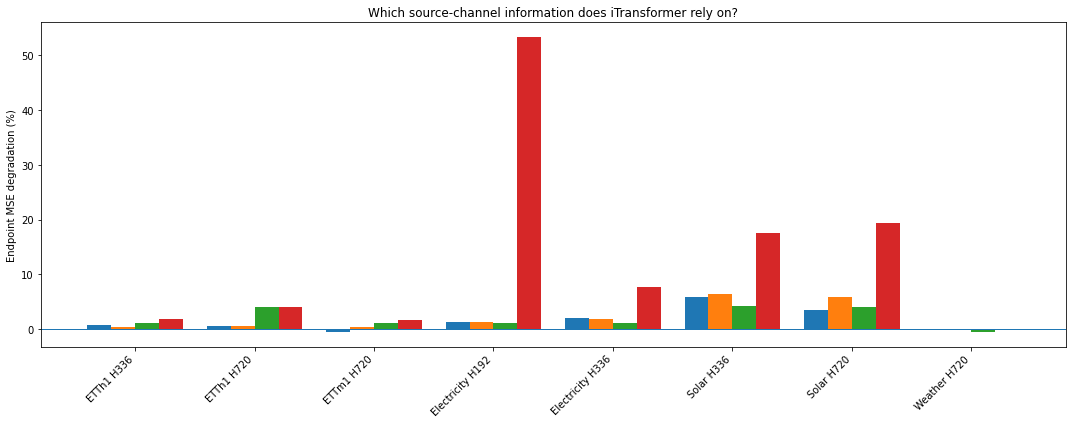

In [27]:
plot_types = [
    "AdaptiveTopK",
    "SharedTopK",
    "MatchedRandomK",
    "AllOtherChannels",
]

plot_df = condition_summary[
    condition_summary[
        "perturb_type"
    ].isin(
        plot_types
    )
].copy()

plot_df[
    "condition"
] = (
    plot_df[
        "dataset"
    ]
    +
    " H"
    +
    plot_df[
        "pred_len"
    ].astype(
        str
    )
)

conditions = (
    plot_df[
        [
            "dataset",
            "pred_len",
            "condition",
        ]
    ]
    .drop_duplicates()
    [
        "condition"
    ]
    .tolist()
)

x = np.arange(
    len(
        conditions
    )
)

width = 0.20

fig, ax = plt.subplots(
    figsize=(
        15,
        6,
    )
)

for p_idx, ptype in enumerate(
    plot_types
):
    sub = (
        plot_df[
            plot_df[
                "perturb_type"
            ]
            ==
            ptype
        ]
        .set_index(
            "condition"
        )
        .reindex(
            conditions
        )
    )

    offset = (
        p_idx
        -
        (
            len(
                plot_types
            )
            -
            1
        )
        /
        2
    ) * width

    ax.bar(
        x
        +
        offset,
        sub[
            "pooled_endpoint_degradation_%"
        ],
        width,
        label=ptype,
    )

ax.axhline(
    0.0,
    linewidth=1,
)

ax.set_xticks(
    x
)

ax.set_xticklabels(
    conditions,
    rotation=45,
    ha="right",
)

ax.set_ylabel(
    "Endpoint MSE degradation (%)"
)

ax.set_title(
    "Which source-channel information does iTransformer rely on?"
)

plt.tight_layout()
plt.show()


## 20. Automatic interpretation


In [28]:
n = len(
    comparison
)

cross_endpoint_n = int(
    comparison[
        "cross_channel_reliance_endpoint"
    ].sum()
)

teacher_endpoint_n = int(
    comparison[
        "teacher_specific_endpoint"
    ].sum()
)

horizon_endpoint_n = int(
    comparison[
        "horizon_specific_endpoint"
    ].sum()
)

mean_all_other = float(
    comparison[
        "AllOtherChannels_endpoint"
    ].mean()
)

mean_teacher_excess = float(
    comparison[
        "adaptive_minus_random_endpoint_pp"
    ].mean()
)

mean_horizon_excess = float(
    comparison[
        "adaptive_minus_shared_endpoint_pp"
    ].mean()
)

mean_self = float(
    comparison[
        "TargetSelf_endpoint"
    ].mean()
)

print(
    "="
    *
    88
)

print(
    "CHANNEL INFORMATION PERMUTATION TEST"
)

print(
    "="
    *
    88
)

print(
    f"Conditions: {n}"
)

print(
    f"AllOther degradation > 0: "
    f"{cross_endpoint_n}/{n}"
)

print(
    f"Adaptive > Random:         "
    f"{teacher_endpoint_n}/{n}"
)

print(
    f"Adaptive > Shared:         "
    f"{horizon_endpoint_n}/{n}"
)

print(
    f"Mean AllOther degradation: "
    f"{mean_all_other:+.3f}%"
)

print(
    f"Mean Adaptive-Random:       "
    f"{mean_teacher_excess:+.3f} pp"
)

print(
    f"Mean Adaptive-Shared:       "
    f"{mean_horizon_excess:+.3f} pp"
)

print(
    f"Mean TargetSelf degradation:"
    f" {mean_self:+.3f}%"
)

print(
    "\nInterpretation:"
)


if (
    cross_endpoint_n
    >=
    6
    and
    teacher_endpoint_n
    >=
    6
    and
    mean_teacher_excess
    >
    0
):
    print(
        "A. STRONG MODEL USES CROSS-CHANNEL INFORMATION, "
        "AND THE PREDICTIVE TEACHER IDENTIFIES IMPORTANT SOURCES."
    )

    if (
        horizon_endpoint_n
        >=
        6
        and
        mean_horizon_excess
        >
        0
    ):
        print(
            "Horizon-specific teacher sources are also more important "
            "than the shared source set."
        )

        print(
            "The earlier hard-mask failure therefore suggests that "
            "forcing/removing interactions is the bottleneck, not "
            "source identification."
        )

    else:
        print(
            "However, horizon-specific sources are not consistently "
            "more important than the shared source set."
        )

        print(
            "The teacher captures useful sources, but not a uniquely "
            "horizon-specific neural topology."
        )


elif (
    cross_endpoint_n
    >=
    6
    and
    (
        teacher_endpoint_n
        <
        6
        or
        mean_teacher_excess
        <=
        0
    )
):
    print(
        "B. STRONG MODEL USES CROSS-CHANNEL INFORMATION, "
        "BUT RIDGE PREDICTIVE UTILITY DOES NOT IDENTIFY "
        "ITS MOST IMPORTANT SOURCES."
    )

    print(
        "This supports model-dependent predictive utility: "
        "linear-source utility and neural-source relevance are distinct."
    )


else:
    print(
        "C. LIMITED CROSS-CHANNEL RELIANCE IN THE STRONG MODEL."
    )

    print(
        "Explicit channel-routing changes are unlikely to provide "
        "large gains under this backbone/protocol."
    )


print(
    "\nRecommended next step:"
)

print(
    "Do not design another router. Use this intervention together with "
    "the Ridge and hard-mask experiments to finalize the mechanism story."
)


CHANNEL INFORMATION PERMUTATION TEST
Conditions: 8
AllOther degradation > 0: 7/8
Adaptive > Random:         4/8
Adaptive > Shared:         3/8
Mean AllOther degradation: +13.167%
Mean Adaptive-Random:       -0.331 pp
Mean Adaptive-Shared:       -0.421 pp
Mean TargetSelf degradation: +123.861%

Interpretation:
B. STRONG MODEL USES CROSS-CHANNEL INFORMATION, BUT RIDGE PREDICTIVE UTILITY DOES NOT IDENTIFY ITS MOST IMPORTANT SOURCES.
This supports model-dependent predictive utility: linear-source utility and neural-source relevance are distinct.

Recommended next step:
Do not design another router. Use this intervention together with the Ridge and hard-mask experiments to finalize the mechanism story.


# 21. Paper interpretation guide

This section implements functional-reliance interventions. Source histories are replaced using matched donor samples while the trained forecaster is kept fixed.
